# 05 · Predict declines and choose an operating threshold

**Question:** how well can a logistic-regression model flag likely declines at request time, and where should the decision threshold sit?

Run `python scripts/build_project.py` first — this notebook reads the executed pipeline's artifacts rather than recomputing them.

In [1]:
import json
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

get_ipython().run_line_magic("matplotlib", "inline")
pd.set_option("display.max_columns", 40)
plt.rcParams.update({"figure.figsize": (9, 4), "axes.spines.top": False, "axes.spines.right": False})

# Anchor on this project specifically: it sits in a subdirectory of a repository
# that has its own pyproject.toml, so "nearest pyproject.toml" is not enough.
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src" / "transfer_decline").is_dir())
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))


In [2]:
metrics = json.loads((ROOT / 'reports' / 'metrics.json').read_text())
selection = json.loads((ROOT / 'artifacts' / 'model_selection.json').read_text())
manifest = json.loads((ROOT / 'artifacts' / 'run_manifest.json').read_text())
print(json.dumps(manifest, indent=2))

{
  "project_version": "0.1.0",
  "generated_utc": "2026-09-09T22:59:00+00:00",
  "seed": 42,
  "python": "3.12.4",
  "platform": "Windows-11-10.0.26200-SP0",
  "packages": {
    "pandas": "2.3.3",
    "numpy": "2.5.3",
    "scikit-learn": "1.9.0",
    "statsmodels": "0.15.0",
    "scipy": "1.18.1"
  },
  "rows_after_clean": 9000,
  "split_counts": {
    "train": 5400,
    "validation": 1800,
    "test": 1800
  },
  "operating_threshold": 0.17,
  "data": "synthetic \u2014 no real patient, facility, or payer data"
}


## Threshold chosen on validation, not test
The default 0.5 cutoff is just the midpoint of a probability scale. What matters is the cost of each error: a **missed decline** (no early warning) is set to cost 5×, a **false alarm** (a coordinator double-checks a request that was fine) 1×. The threshold that minimises expected weighted cost is picked on the **validation** split, then frozen.

{
  "threshold": 0.17,
  "validation_weighted_cost": 691.0,
  "validation_precision": 0.29338842975206614,
  "validation_recall": 0.4057142857142857,
  "cost_false_negative": 5.0,
  "cost_false_positive": 1.0,
  "default_threshold_cost": 867.0
}


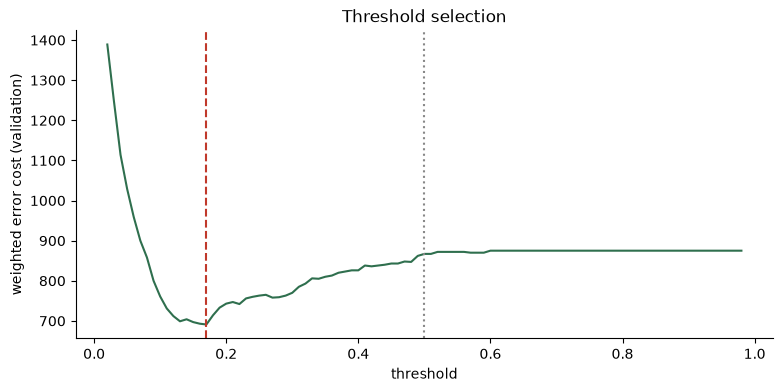

In [3]:
print(json.dumps(selection, indent=2))
curve = pd.read_csv(ROOT / 'reports' / 'threshold_cost_curve.csv')
ax = curve.plot(x='threshold', y='weighted_cost', legend=False, color='#2f6f4e')
ax.axvline(selection['threshold'], color='#c0392b', ls='--')
ax.axvline(0.5, color='#888', ls=':')
ax.set_ylabel('weighted error cost (validation)'); plt.title('Threshold selection'); plt.show()

## Held-out test performance

In [4]:
rows = []
for split in ['train', 'validation', 'test']:
    m = metrics['splits'][split]
    rows.append({'split': split, **{k: m[k] for k in ['n','roc_auc','pr_auc','brier','precision','recall','f1','specificity','weighted_cost']}})
display(pd.DataFrame(rows).set_index('split').round(3))
print('test confusion matrix at operating threshold:', metrics['splits']['test']['confusion_matrix'])
print('test confusion matrix at default 0.50     :', metrics['splits']['test_default_threshold']['confusion_matrix'])

,n,roc_auc,pr_auc,brier,precision,recall,f1,specificity,weighted_cost
split,,,,,,,,,
train,5400,0.784,0.461,0.119,0.335,0.738,0.461,0.691,2612.0
validation,1800,0.736,0.271,0.080,0.293,0.406,0.341,0.895,691.0
test,1800,0.757,0.423,0.133,0.372,0.653,0.474,0.746,956.0


test confusion matrix at operating threshold: {'tn': 1092, 'fp': 371, 'fn': 117, 'tp': 220}
test confusion matrix at default 0.50     : {'tn': 1446, 'fp': 17, 'fn': 312, 'tp': 25}


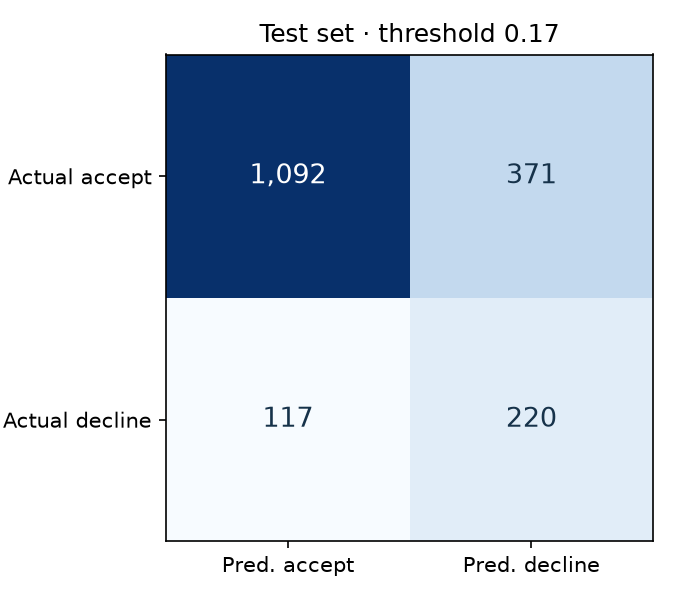

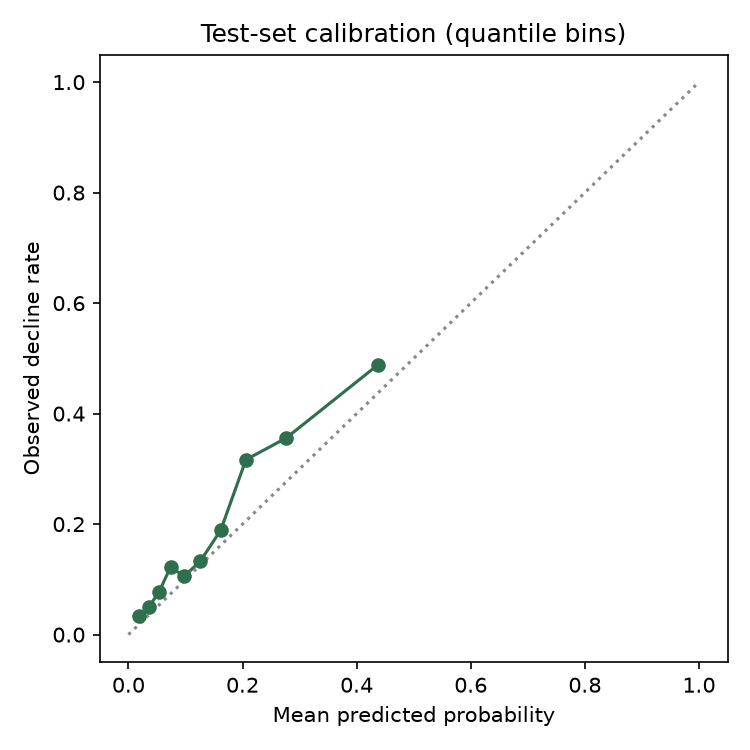

In [5]:
from IPython.display import Image
display(Image(filename=str(ROOT / 'reports' / 'figures' / 'confusion_test.png')))
display(Image(filename=str(ROOT / 'reports' / 'figures' / 'calibration_test.png')))

## What drives the score

In [6]:
coef = pd.read_csv(ROOT / 'reports' / 'coefficients.csv')
display(coef.head(15).round(3))

,feature,coefficient,odds_ratio
0,requested_service_line_Trauma,-1.084,0.338
1,requested_service_line_Neurology / Stroke,-1.037,0.355
2,medsurg_occupancy_pct,0.761,2.140
3,referring_facility_type_Skilled Nursing Facility,0.670,1.955
4,requested_service_line_GI,0.579,1.784
5,requested_service_line_Oncology,0.551,1.736
6,requested_service_line_Orthopedics,0.538,1.713
7,referring_facility_type_Community Hospital Inp...,-0.422,0.656
8,transport_mode_Rotor Wing,-0.415,0.660
9,referring_facility_Referring Facility B,-0.413,0.662


## Operational reading
The model recovers the capacity-and-acuity story from notebook 02: occupancy, ED boarding, ICU level of care, and higher acuity push decline odds up. Moving the threshold below 0.5 trades some precision for materially higher recall on declines, which is the point when a missed decline is the costlier error.

**Limits.** Synthetic data with designed relationships; a single logistic model; illustrative rather than measured error costs; the chronological split still shares a generator across periods. This supports a reproducible workflow and a defensible threshold argument — not a claim about real transfer-center performance or about any payer group.